## Kaggle、NLP 和 HuggingFace 绝对初学者入门指南


近年来，深度学习在自然语言处理（NLP）领域取得了显著进步。计算机现在能够生成文本、在不同语言之间自动翻译、分析评论、标注句子中的词语，以及完成更多任务。

NLP 中最具实际应用价值的方向或许是<em>分类</em>——即自动将文档归入某个类别。例如，它可以用于：

- 情感分析（例如，了解人们对您的产品持<em>正面</em>还是<em>负面</em>的看法）
- 作者识别（判断某篇文档最可能出自哪位作者）
- 法律文件筛查（确定哪些文件与某次庭审相关）
- 按主题整理文档
- 对收到的邮件进行分类处理
- ……以及更多应用场景！

分类模型还可以用来解决一些乍看之下并不适合用分类方法处理的问题。以 Kaggle 上的 [U.S. Patent Phrase to Phrase Matching](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching/) 竞赛为例。该竞赛要求我们比较两个词语或短语，并根据它们在所属专利类别中的语义相似程度进行打分。分数为 `1` 表示两个输入含义完全相同，`0` 则表示含义完全不同。例如，*abatement* 与 *eliminating process* 的得分为 `0.5`，意味着两者有一定相似性，但并不完全相同。

事实上，这个问题可以转化为一个分类任务。怎么做到的呢？只需像下面这样来表述问题：

> 对于以下文本："TEXT1: abatement; TEXT2: eliminating process"，请从以下类别中选择最符合的语义相似度："Different; Similar; Identical"。

在本笔记本中，我们将学习如何通过将专利短语匹配问题转化为分类任务来求解，其表述方式与上述示例非常相似。


### 关于 Kaggle


Kaggle 对于有志于数据科学的朋友，或任何希望提升机器学习技能的人来说，都是一个极好的资源。没有什么比动手实践、获得实时反馈更能帮助你快速进步了。它提供：

1. 有趣的数据集
1. 关于你学习进度的反馈
1. 排行榜，让你了解什么是优秀、什么是可能，以及什么是当前最先进的水平
1. 获奖参赛者分享的 Notebook 和博客文章，其中包含实用的技巧与方法。

我们在这里使用的数据集仅可从 Kaggle 获取。因此，你需要先在该网站注册，然后前往[竞赛页面](https://www.kaggle.com/c/us-patent-phrase-to-phrase-matching)。在该页面点击"Rules"，再点击"I Understand and Accept"。（虽然竞赛已经结束，你也不会参加，但仍需同意规则才能下载数据。）

之后，有两种方式使用这份数据：

- 最简单：直接在 Kaggle 上运行本 Notebook，或者
- 最灵活：将数据下载到本地，在你的电脑或 GPU 服务器上运行

如果你是在 Kaggle.com 上运行，可以跳过下一节。只需确保在 Kaggle 上已选择使用 GPU，方法是点击汉堡菜单（右上角的三个点），然后点击"Accelerator"——界面应如下所示：


<div>
<img src="../../../slides/image.png" width="400">
</div>

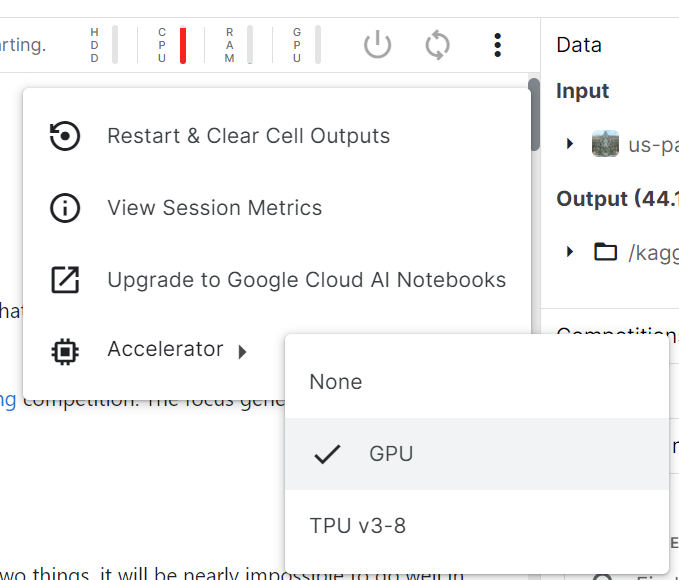

### 在您自己的机器上使用 Kaggle 数据


Kaggle 对使用 GPU 机器的每周时长有所限制。限额已经相当宽裕，但你可能仍会发现不够用！在这种情况下，你可以使用自己的 GPU 服务器，或者 Colab、Paperspace Gradient、SageMaker Studio Lab 等云服务器（这些都有免费选项）。为此，你需要能够下载 Kaggle 数据集。

下载 Kaggle 数据集最简单的方式是使用 Kaggle API。你可以在 notebook 单元格中运行以下命令，通过 `pip` 安装：

    !pip install kaggle

使用 Kaggle API 需要一个 API 密钥；要获取密钥，请点击 Kaggle 网站上的头像，选择"我的账户"，然后点击"创建新 API Token"。这会将一个名为 *kaggle.json* 的文件保存到你的电脑上。你需要将此密钥复制到你的 GPU 服务器上。方法是：打开下载的文件，复制其中的内容，并粘贴到以下单元格中（例如：`creds = '{"username":"xxx","key":"xxx"}'`）：


In [6]:
creds = ''

然后执行此单元格（只需运行一次）：


In [7]:
# for working with paths in Python, I recommend using `pathlib.Path`
from pathlib import Path

cred_path = Path('~/.kaggle/kaggle.json').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

现在您可以从 Kaggle 下载数据集了。


In [8]:
path = Path('us-patent-phrase-to-phrase-matching')

然后使用 Kaggle API 将数据集下载到该路径，并解压：


In [9]:
from zipfile import ZipFile

if not path.exists():
    from kaggle import api
    api.competition_download_cli(str(path))
    ZipFile(f'{path}.zip').extractall(path)

## 导入与探索性数据分析


NLP 数据集中的文档通常有以下两种主要形式：

- <strong>较大的文档</strong>：每个文档对应一个文本文件，通常按类别分别存放在不同的文件夹中
- <strong>较小的文档</strong>：每行对应一个文档（或文档对，可选包含元数据），存储在 <a href="https://realpython.com/python-csv/">CSV 文件</a>中。

让我们来看看我们的数据，了解一下具体情况。在 Jupyter 中，你可以在行首加上 `!` 来执行任意 bash/shell 命令，并使用 `{}` 来嵌入 Python 变量，如下所示：


In [10]:
!ls {path}

sample_submission.csv  test.csv  train.csv


看起来这个竞赛使用的是 CSV 文件。对于打开、操作和查看 CSV 文件，通常最好使用 Pandas 库，该库由首席开发者在[这本书](https://wesmckinney.com/book/)中有精彩的讲解（这也是对 matplotlib 和 numpy 的绝佳入门介绍，我在本笔记本中都有使用）。通常它以缩写 `pd` 导入。


In [11]:
import pandas as pd

让我们设置数据路径：


In [12]:
df = pd.read_csv(path/'train.csv')

这将创建一个 [DataFrame](https://pandas.pydata.org/docs/user_guide/10min.html)，它是一个由命名列组成的表格，有点像数据库表。要查看 DataFrame 的第一行和最后几行以及行数，只需输入其名称：


In [13]:
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


仔细阅读[数据集说明](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching/data)以了解每列的用途非常重要。

`DataFrame` 最实用的功能之一是 `describe()` 方法：


In [14]:
df.describe(include='object')

,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186


在这 36473 行数据中，共有 733 个唯一锚点、106 个上下文，以及近 30000 个目标词。部分锚点出现频率极高，例如"component composite coating"就出现了 152 次。

之前我提到，可以将模型的输入表示为类似"*TEXT1: abatement; TEXT2: eliminating process*"的形式。我们还需要在其中加入上下文信息。在 Pandas 中，直接用 `+` 进行字符串拼接即可，如下所示：


In [15]:
df['input'] = 'TEXT1: ' + df.context + '; TEXT2: ' + df.target + '; ANC1: ' + df.anchor

我们可以使用常规 Python "点式"表示法或像字典一样访问来引用列（也称为<em>系列</em>）。要获取前几行，请使用 `head()`：


In [16]:
df.input.head()

0    TEXT1: A47; TEXT2: abatement of pollution; ANC...
1    TEXT1: A47; TEXT2: act of abating; ANC1: abate...
2    TEXT1: A47; TEXT2: active catalyst; ANC1: abat...
3    TEXT1: A47; TEXT2: eliminating process; ANC1: ...
4    TEXT1: A47; TEXT2: forest region; ANC1: abatement
Name: input, dtype: object

## 标记化


Transformers 使用 `Dataset` 对象来存储……嗯，当然是数据集！我们可以像这样创建一个：


In [17]:
from datasets import Dataset,DatasetDict

ds = Dataset.from_pandas(df)

以下是它在笔记本中的显示方式：


In [18]:
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

但我们不能直接将文本传入模型。深度学习模型期望的输入是数字，而不是英文句子！所以我们需要做两件事：

- <em>分词</em>：将每段文本拆分成单词（实际上，正如我们将看到的，是拆分成<em>词元</em>）
- <em>数值化</em>：将每个单词（或词元）转换为一个数字。

具体的处理方式实际上取决于我们所使用的模型。因此，我们首先需要选择一个模型。目前有数千个模型可供选择，但对于几乎任何自然语言处理问题，一个合理的起点是使用以下这个（在完成初步探索后，可以将 "small" 替换为 "large"，以获得速度较慢但更准确的模型）：


In [19]:
model_nm = 'microsoft/deberta-v3-small'

`AutoTokenizer` 将为给定模型创建合适的分词器：


In [20]:
from transformers import AutoModelForSequenceClassification,AutoTokenizer
tokz = AutoTokenizer.from_pretrained(model_nm)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


以下是分词器如何将文本拆分为"词元"（token）的示例（词元类似于单词，但也可以是子词片段，如下所示）：


In [21]:
tokz.tokenize("G'day folks, I'm Jeremy from fast.ai!")

['▁G',
 "'",
 'day',
 '▁folks',
 ',',
 '▁I',
 "'",
 'm',
 '▁Jeremy',
 '▁from',
 '▁fast',
 '.',
 'ai',
 '!']

不常见的单词将被拆分成片段。新单词的开头用 `▁` 表示：


In [22]:
tokz.tokenize("A platypus is an ornithorhynchus anatinus.")

['▁A',
 '▁platypus',
 '▁is',
 '▁an',
 '▁or',
 'ni',
 'tho',
 'rhynch',
 'us',
 '▁an',
 'at',
 'inus',
 '.']

这是一个简单的函数，用于对我们的输入进行分词：


In [23]:
def tok_func(x): return tokz(x["input"])

要在数据集的每一行上快速并行运行，请使用 `map`：


In [ ]:
tok_ds = ds.map(tok_func, batched=True)

  0%|          | 0/37 [00:00<?, ?ba/s]

这将向我们的数据集添加一个名为 `input_ids` 的新项目。例如，以下是我们数据第一行的输入和 ID：


In [ ]:
row = tok_ds[0]
row['input'], row['input_ids']

那么，这些 ID 是什么，它们从哪里来？秘密在于分词器中有一个叫做 `vocab` 的列表，其中包含每个可能的词元字符串对应的唯一整数。我们可以像这样查找它们，例如查找单词 "of" 的词元：


In [ ]:
tokz.vocab['▁of']

查看上面的输入 ID，我们确实可以看到 `265` 如预期出现。

最后，我们需要准备标签。Transformers 始终假定标签列名为 `labels`，但在我们的数据集中，该列目前名为 `score`。因此，我们需要将其重命名：


In [ ]:
tok_ds = tok_ds.rename_columns({'score':'labels'})

现在我们已经准备好了令牌和标签，我们需要创建我们的验证集。


## 测试集与验证集


您可能已经注意到，我们的目录中包含另一个文件：


In [ ]:
eval_df = pd.read_csv(path/'test.csv')
eval_df.describe()

这是<em>测试集</em>。机器学习中最重要的概念之一，是将数据分为独立的训练集、验证集和测试集。


### 验证集


为了解释动机，让我们从简单的开始，假设我们正在尝试拟合一个模型，其中真实关系是这个二次函数：


In [ ]:
def f(x): return -3*x**2 + 2*x + 20

不幸的是，matplotlib（Python 中最常见的绘图库）没有提供可视化函数的方法，所以我们将自己编写一些东西来实现这一点：


In [ ]:
import numpy as np, matplotlib.pyplot as plt

def plot_function(f, min=-2.1, max=2.1, color='r'):
    x = np.linspace(min,max, 100)[:,None]
    plt.plot(x, f(x), color)

我们的函数如下所示：


In [ ]:
plot_function(f)

例如，也许我们在某个事件发生前后测量了一个物体距地面的高度。这些测量值会存在一些随机误差。我们可以使用 numpy 的随机数生成器来模拟这一点。在编写此类模拟时，我喜欢使用 `seed`，这样我就能确保你看到的结果与我看到的相同：


In [ ]:
from numpy.random import normal,seed,uniform
np.random.seed(42)

这是一个 `add_noise` 函数，它为数组添加一些随机变化：


In [ ]:
def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

让我们用它来模拟一些随时间均匀分布的测量值：


In [ ]:
x = np.linspace(-2, 2, num=20)[:,None]
y = add_noise(f(x), 0.2, 1.3)
plt.scatter(x,y);

现在让我们看看如果我们对这些预测进行<em>欠拟合</em>或<em>过拟合</em>会发生什么。为此，我们将创建一个函数，用于拟合某个次数的多项式（例如，一次是1次，二次是2次，三次是3次，等等）。这个函数的工作原理细节不太重要，所以如果你愿意的话，可以跳过它！（附：如果你不确定多项式相关的术语，这里有一个[很棒的视频](https://www.youtube.com/watch?v=ffLLmV4mZwU)，可以教你需要了解的知识。）


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def plot_poly(degree):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x, y)
    plt.scatter(x,y)
    plot_function(model.predict)

那么，如果我们将一条直线（"1次多项式"）拟合到我们的测量数据中，会发生什么？


In [ ]:
plot_poly(1)

如您所见，红线（我们拟合的直线）上的点与实际数据相差甚远。这就是<em>欠拟合</em>——我们的函数不够复杂，无法很好地拟合数据。

那么，如果我们用一个10次多项式来拟合数据，会发生什么呢？


In [ ]:
plot_poly(10)

现在模型虽然更贴合我们的数据，但对于那些未被测量的点——尤其是更早或更晚时间段的点——预测效果恐怕并不理想。这就是<em>过拟合</em>——模型过于精细地拟合了我们的数据点，却偏离了我们真正关心的底层规律。

让我们试试2次多项式（二次函数），并将其与"真实"函数（蓝色）进行比较：


In [ ]:
plot_poly(2)
plot_function(f, color='b')

还不错！

那么，我们如何判断模型是欠拟合、过拟合，还是"恰到好处"呢？我们使用<em>验证集</em>。验证集是一部分我们"留出"不参与训练的数据——模型完全看不到这部分数据。如果你使用 fastai 库，它会在你没有提供验证集的情况下自动为你创建一个，并始终使用验证集来报告指标（即衡量模型准确性的测量值）。

验证集<em>只</em>用于评估模型的表现，<em>绝不</em>用作训练模型的输入。

Transformers 使用 `DatasetDict` 来存储训练集和验证集。要创建一个包含 20% 验证数据和 80% 训练数据的数据集，请使用 `train_test_split`：


In [ ]:
dds = tok_ds.train_test_split(0.25, seed=42)
dds

如上所示，这里的验证集被称为 `test` 而不是 `validate`，请注意！


### 测试集


这就是验证集的说明与创建方式。那么"测试集"又是什么，有什么用途呢？

<em>测试集</em>是另一个从训练中保留下来的数据集。但它不仅从训练中保留，也不用于报告指标！只有在完成整个训练流程之后——包括尝试不同的模型、训练方法、数据处理等——才会检验模型在测试集上的准确率。

你看，当你不断尝试各种方法、观察它们对验证集指标的影响时，可能会偶然发现一些看似提升了验证集指标、但实际上并没有真正改善效果的做法。随着时间推移和实验次数增多，这类"巧合性提升"会越来越多。这意味着你实际上是在对验证集过拟合！

这就是我们保留测试集的原因。Kaggle 的公开排行榜就像一个可以偶尔查看的测试集。但不要查得太频繁，否则你又会对测试集过拟合了！

Kaggle 还有一个<em>第二</em>测试集，这是另一个隐藏数据集，仅在比赛结束时用于评估你的预测结果，称为"私有排行榜"。关于过拟合公开排行榜可能带来的后果，这里有一篇[精彩文章](https://gregpark.io/blog/Kaggle-Psychopathy-Postmortem/)值得一读。

我们将用 `eval` 作为测试集的名称，以避免与上面创建的 `test` 数据集混淆。


In [ ]:
eval_df['input'] = 'TEXT1: ' + eval_df.context + '; TEXT2: ' + eval_df.target + '; ANC1: ' + eval_df.anchor
eval_ds = Dataset.from_pandas(eval_df).map(tok_func, batched=True)

## 指标与相关性


在训练模型时，我们会关注一个或多个希望最大化或最小化的<em>指标</em>。这些指标应该能够在理想情况下反映模型的实际表现。

在现实生活中，Kaggle 之外的世界并不那么简单……正如我的伙伴 Rachel Thomas 博士在 [The problem with metrics is a big problem for AI](https://www.fast.ai/2019/09/24/metrics/) 中所指出的：

>  当今大多数 AI 方法的核心，都是对指标进行优化。优化指标的做法并非 AI 独有，也不是新鲜事，但 AI 在这方面可以表现得极为高效（甚至过于高效！）。理解这一点至关重要，因为优化指标本身存在的风险，会因 AI 而被进一步放大。指标在适当的场合固然有用，但若不加思考地滥用，则会带来危害。那些最令人担忧的算法失控案例，无一不源于对指标的过度追求。我们必须理解这一动态，才能认清因滥用 AI 而面临的紧迫风险。

不过在 Kaggle 中，选择什么指标非常明确：Kaggle 会直接告诉你！根据本次竞赛的[评估页面](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching/overview/evaluation)，"*提交结果将以预测相似度分数与实际相似度分数之间的[皮尔逊相关系数](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)进行评估。*"该系数通常用单个字母 *r* 表示，是衡量两个变量之间关联程度最广泛使用的指标。

r 的取值范围在 `-1` 到 `+1` 之间，`-1` 表示完全负相关，`+1` 表示完全正相关。相比记住它的数学公式，更重要的是对不同取值所呈现的规律建立良好的直觉。为了培养这种直觉，我们来看一些基于 [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) 数据集的示例，该数据集展示了"*加利福尼亚各地区的房价中位数，以十万美元为单位*"。该数据集由优秀的 [scikit-learn](https://scikit-learn.org/stable/) 库提供——这是深度学习之外应用最广泛的机器学习库。


In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
housing = housing['data'].join(housing['target']).sample(1000, random_state=52)
housing.head()

我们可以通过调用 `np.corrcoef` 来查看该数据集中每列组合的所有相关系数：


In [ ]:
np.set_printoptions(precision=2, suppress=True)

np.corrcoef(housing, rowvar=False)

当我们一次获取一组值时，这种方法效果很好，但当我们只想要单个系数时，它就显得过于繁琐了：


In [ ]:
np.corrcoef(housing.MedInc, housing.MedHouseVal)

因此，我们将创建这个小函数，给定一对变量，只返回我们需要的单个数字：


In [ ]:
def corr(x,y): return np.corrcoef(x,y)[0][1]

corr(housing.MedInc, housing.MedHouseVal)

现在我们来看几个相关性的例子，使用这个函数（函数的细节不太重要）：


In [ ]:
def show_corr(df, a, b):
    x,y = df[a],df[b]
    plt.scatter(x,y, alpha=0.5, s=4)
    plt.title(f'{a} vs {b}; r: {corr(x, y):.2f}')

好的，让我们来看看收入与房价之间的相关性：


In [ ]:
show_corr(housing, 'MedInc', 'MedHouseVal')

所以，0.68 的相关性看起来就是这样。这是一个相当紧密的关系，但仍然存在相当大的波动。（顺便提一句，这也说明了为什么查看数据如此重要——从这张图中我们可以清楚地看到，超过 500,000 美元的房价似乎被截断到了该最大值。）

让我们再来看看另一对：


In [ ]:
show_corr(housing, 'MedInc', 'AveRooms')

从图形上看，这段关系与前面的例子同样紧密，但 r 值却远低于收入与估值的情况。原因在于数据中存在大量<em>异常值</em>——`AveRooms` 的某些值远偏离均值。

r 对异常值非常敏感。如果数据中存在异常值，它们之间的关系就会主导整个指标。在这个案例中，房间数极多的房屋往往并不特别值钱，因此将 r 从本应有的水平拉低了。

让我们剔除异常值后再试一次：


In [ ]:
subset = housing[housing.AveRooms<15]
show_corr(subset, 'MedInc', 'AveRooms')

正如我们所预期的，现在的相关性与我们第一次比较的结果非常相似。

以下是使用 `AveRooms` 在子集上的另一个关系：


In [ ]:
show_corr(subset, 'MedHouseVal', 'AveRooms')

在这个层级上，r 值为 0.34，相关性已经相当微弱了。

我们再来看一个：


In [ ]:
show_corr(subset, 'HouseAge', 'AveRooms')

如您所见，-0.2 的相关系数表示一个非常微弱的负相关趋势。

我们已经看过了各种相关系数水平的示例，希望您对这个指标的含义有了更直观的感受。

Transformers 要求以 `dict` 的形式返回指标，这样训练器就能知道使用什么标签，所以让我们来创建一个函数来实现这一点：


In [ ]:
def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}

## 训练


## 训练我们的模型


要在 Transformers 中训练模型，我们需要以下内容：


In [ ]:
from transformers import TrainingArguments,Trainer

我们选择一个适合我们 GPU 的批量大小，以及较少的训练轮数，以便我们可以快速运行实验：


In [ ]:
bs = 128
epochs = 4

最重要的超参数是学习率。fastai 提供了一个学习率查找器来帮助你找到合适的值，但 Transformers 没有这个功能，所以你只能通过反复试验来确定。其思路是找到尽可能大的值，但又不会导致训练失败。


In [ ]:
lr = 8e-5

Transformers 使用 `TrainingArguments` 类来设置参数。不必太担心我们在这里使用的值——在大多数情况下它们通常都能正常工作。只有上面这 3 个参数可能需要根据不同的模型进行更改。


In [ ]:
args = TrainingArguments('outputs', learning_rate=lr, warmup_ratio=0.1, lr_scheduler_type='cosine', fp16=True,
    evaluation_strategy="epoch", per_device_train_batch_size=bs, per_device_eval_batch_size=bs*2,
    num_train_epochs=epochs, weight_decay=0.01, report_to='none')

现在我们可以创建我们的模型和 `Trainer`，它是一个将数据和模型组合在一起的类（就像 fastai 中的 `Learner`）：


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=1)
trainer = Trainer(model, args, train_dataset=dds['train'], eval_dataset=dds['test'],
                  tokenizer=tokz, compute_metrics=corr_d)

如您所见，Transformers 会输出大量警告信息，可以放心忽略。

让我们开始训练模型吧！


In [ ]:
trainer.train();

---

<!-- CO-OP TRANSLATOR DISCLAIMER START -->
**免责声明**：
本文档已使用 AI 翻译服务 [Co-op Translator](https://github.com/Azure/co-op-translator) 进行翻译。尽管我们努力确保准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的原始文档应被视为权威来源。对于重要信息，建议使用专业人工翻译。对于因使用本翻译而产生的任何误解或误读，我们概不负责。
<!-- CO-OP TRANSLATOR DISCLAIMER END -->
